In [359]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy
from sklearn.model_selection import KFold
import scipy.stats as stats

phot_data = pd.read_csv("string_phot_rat_data.csv")
data = phot_data.drop(columns=['percentage_x', 'x_reach_centered', 'y_reach_centered', 'rat'])
data = data.dropna()
# seperate data into testing and training dat
# find random indexes that account for around 25% of the data
test_ix = numpy.random.randint(0, data.shape[0],round(data.shape[0]/4))
test_data = data.iloc[test_ix].copy()
# get a list of the indicies to keep in the training data
train_ix = list(set(range(data.shape[0])) - set(test_ix))
train_data = data.iloc[train_ix].copy()

X_train = train_data.drop(columns=['df_centered'])
y_train = train_data['df_centered'].to_numpy()

X_test = test_data.drop(columns=['df_centered'])
y_test = test_data['df_centered'].to_numpy()

In [350]:
def linear_regression_gradient_descent(X, y):
    if len(X.shape) > 1:
        n_samples, n_features = X.shape
        weights = numpy.zeros(n_features)
    else:
        n_samples = X.size
        n_features = 1
        weights = 0
    # implement gradient descent
    # set initial weights and biases
    bias = 1
    learning_rate = 0.001
    epochs = 10000

    # fit the model
    for epoch in range(epochs):
        # calculate predicted y
        y_predicted = numpy.dot(X, weights) + bias
        # get the error for weights and bias
        diff_w = (1/n_samples) * numpy.dot(X.T, (y_predicted - y))
        diff_b = (1/n_samples) * numpy.sum(y_predicted - y)  

        # update weights and biases
        weights -= learning_rate*diff_w
        bias -= learning_rate*diff_b
    return weights, bias


def calculate_RSE(y_pred, y, n_sample, n_params):
    rss = numpy.sum((y_pred - y)**2)
    rse = numpy.sqrt(rss/(n_sample-n_params-1))
    return rse

def calculate_SE(x, rse):
    se = rse/numpy.sqrt(numpy.sum((x-numpy.mean(x))**2))
    return se

def calculate_R2(y, y_pred):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y - y_pred))
    R2 = 1 - (RSS/TSS)
    return R2

def calculate_adjusted_R2(y, y_pred, n, p):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    RSS = numpy.sum(numpy.square(y - y_pred))
    R2 = 1 - ((RSS/(n - p - 1))/(TSS/(n - 1)))
    return R2


def calculate_F(y, y_pred, n_features, n_samples):
    TSS = numpy.sum(numpy.square(y - numpy.mean(y)))
    # compute the residual sum of squares
    RSS = numpy.sum(numpy.square(y-y_pred))
    F = ((TSS-RSS)/n_features)/((RSS)/(n_samples - n_features - 1))
    return F

def calculate_tstat(x, rse, B):
    se = calculate_SE(x, rse)
    tstat = B/se
    return tstat


def k_fold_cross_val(X, y, n_samples, n_params):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rses = []
    r2s = []
    for trainIX, testIX in kf.split(y):
        train_X, test_X = X[trainIX], X[testIX]
        train_y, test_y = y[trainIX], y[testIX]
        weight, bias = linear_regression_gradient_descent(train_X, train_y)
        y_pred = numpy.dot(test_X, weight) + bias
        rse = calculate_RSE(y_pred, test_y, len(test_y), n_params)
        rses.append(rse)
        adjusted_R2 = calculate_adjusted_R2(test_y, y_pred, len(test_y), n_params)
        r2s.append(adjusted_R2)
    rse =  numpy.mean(rses)
    adj_r2 = numpy.mean(r2s)
    return rse, adj_r2       

In [324]:
def simple_reg_for_each_parameter(X_df, y):    
    simple_reg_dict = {}
    for param in X_df.columns:
        X = X_df[param].to_numpy()
        rse, adj_r2 = k_fold_cross_val(X, y, X.size, 1)
        simple_reg_dict[param] = [rse, adj_r2]
    return simple_reg_dict

In [378]:
def simple_reg_for_each_parameter_eval(X_train, y_train, X_test, y_test):    
    simple_reg_dict = {}
    for param in X_train.columns:
        X = X_train[param].to_numpy()
        test_X = X_test[param].to_numpy()
        weight, bias = linear_regression_gradient_descent(X, y_train)
        y_pred = weight*test_X + bias
        residuals = y_pred - y_test
        F = calculate_F(y_test, y_pred, X_test.shape[1], X_test.shape[0])
        p_val = 1 - stats.f.cdf(F, 1, X_test.shape[0] - 2)
        simple_reg_dict[param] = [bias, weight, F, p_val]
        plt.figure()
        plt.scatter(X_test[param], y_test)
        plt.axline(xy1=(0,bias), slope=weight)
        plt.xlabel(param)

    return pd.DataFrame(simple_reg_dict)

,x_pos_centered,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
0,5.059507e-05,5.139272e-05,0.000053,5.245838e-05,5.168794e-05
1,-1.502038e-03,-6.235548e-04,-0.000115,-4.450823e-05,-3.023832e-05
2,1.278315e+02,8.967964e+01,-0.031919,2.493925e+01,2.961675e+01
3,1.110223e-16,1.110223e-16,1.000000,5.946365e-07,5.301830e-08


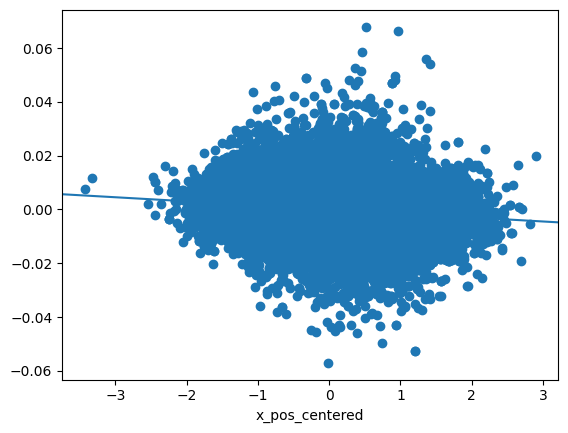

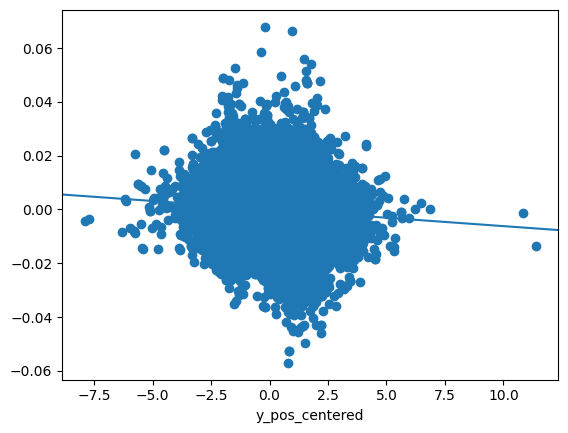

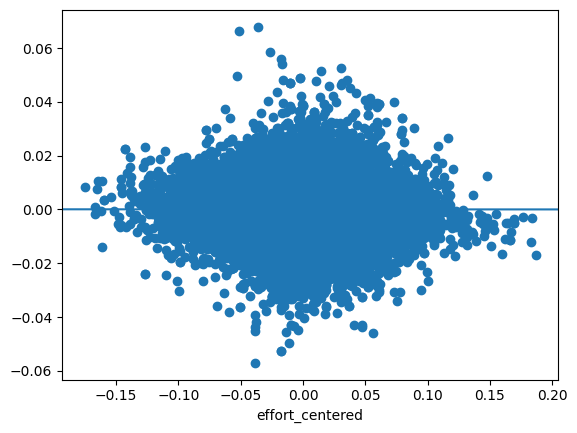

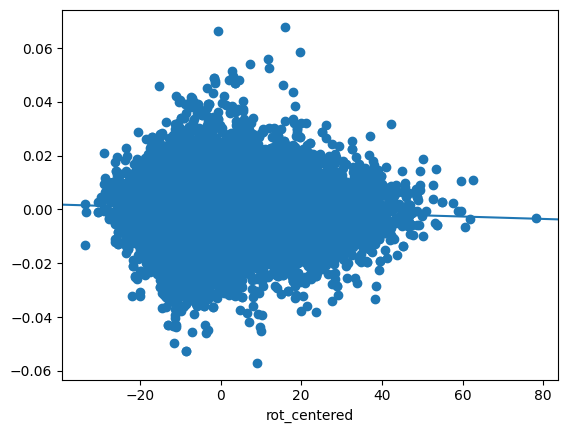

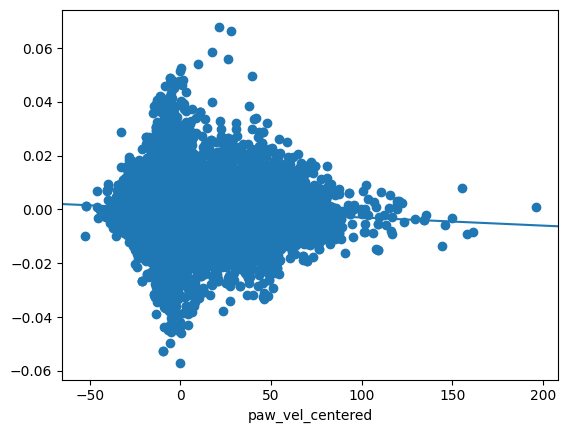

In [379]:
simple_reg_for_each_parameter_eval(X_train, y_train, X_test, y_test)

In [325]:
X_df = train_data.drop(columns=['df_centered'])
X = X_df.to_numpy()
y = train_data['df_centered'].to_numpy()

simple = simple_reg_for_each_parameter(X_df, y)

In [327]:
pd.DataFrame(simple, index=['rse', 'adj_r2']).head()

,x_pos_centered,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
rse,0.008625,0.008656,0.008705,0.008689,0.008685
adj_r2,0.018247,0.011107,-0.000074,0.003419,0.004505


In [328]:
def multiple_linreg(X, y):
    n_samples, n_features = X.shape
    rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
    return rse, adj_r2

In [400]:
rses = []
r2s = []
for param in X_df.drop(columns=['x_pos_centered']).columns:
        params = ['x_pos_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        rses.append(rse)
        r2s.append(adj_r2)
pd.DataFrame([rses, r2s], index=['R^2', 'adjusted R^2'], columns=X_df.drop(columns=['x_pos_centered']).columns)

,y_pos_centered,effort_centered,rot_centered,paw_vel_centered
R^2,0.008615,0.008625,0.008625,0.008625
adjusted R^2,0.020429,0.018208,0.018198,0.018212


In [401]:
rses = []
r2s = []
for param in X_df.drop(columns=['x_pos_centered', 'y_pos_centered']).columns:
        params = ['x_pos_centered', 'y_pos_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        rses.append(rse)
        r2s.append(adj_r2)
pd.DataFrame([rses, r2s], index=['R^2', 'adjusted R^2'], columns=X_df.drop(columns=['x_pos_centered', 'y_pos_centered']).columns)

,effort_centered,rot_centered,paw_vel_centered
R^2,0.008615,0.008615,0.008615
adjusted R^2,0.020394,0.020398,0.020322


In [402]:
rses = []
r2s =[]
for param in X_df.drop(columns=['x_pos_centered', 'y_pos_centered', 'rot_centered']).columns:
        params = ['x_pos_centered', 'y_pos_centered', 'rot_centered']
        params.append(param)
        X = X_df[params].to_numpy()
        n_samples, n_features = X.shape
        rse, adj_r2 = k_fold_cross_val(X, y, n_samples, n_features)
        rses.append(rse)
        r2s.append(adj_r2)
pd.DataFrame([rses, r2s], index=['R^2', 'adjusted R^2'], columns=X_df.drop(columns=['x_pos_centered', 'y_pos_centered', 'rot_centered']).columns)

,effort_centered,paw_vel_centered
R^2,0.008615,0.008616
adjusted R^2,0.020363,0.020300


0.020266255568667502


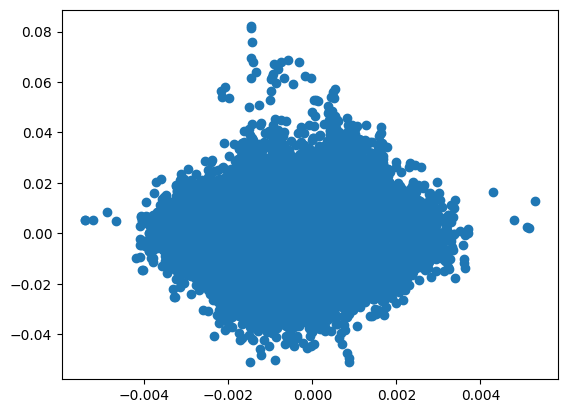

In [313]:
weight, bias, rse, r2 = multiple_linreg(X_df.to_numpy(), y)
print(r2)

In [314]:
print(rse, r2)

0.008615689466741875 0.020266255568667502


In [392]:
def multiple_linreg_eval(X_train, y_train, X_test, y_test, title_str):
    n_samples, n_features = X.shape
    weights, bias = linear_regression_gradient_descent(X_train, y_train)
    test_X = X_test.to_numpy()
    y_pred = numpy.dot(test_X, weights)
    residuals = y_pred - y_test
    F = calculate_F(y_test, y_pred, X_test.shape[1], X_test.shape[0])
    p_val = 1 - stats.f.cdf(F, X_test.shape[1], X_test.shape[0] - X_test.shape[1])
    plt.figure()
    plt.scatter(y_pred, residuals)
    plt.xlabel('Predicted y values')
    plt.ylabel('Residuals')
    plt.title(title_str)
    return bias, weight, F, p_val

(np.float64(5.036650669163437e-05),
 array([-1.07102144e-03, -3.57299059e-04, -1.03817387e-04, -4.32627652e-06,
        -3.52729902e-06]),
 np.float64(150.63715324857947),
 np.float64(1.1102230246251565e-16))

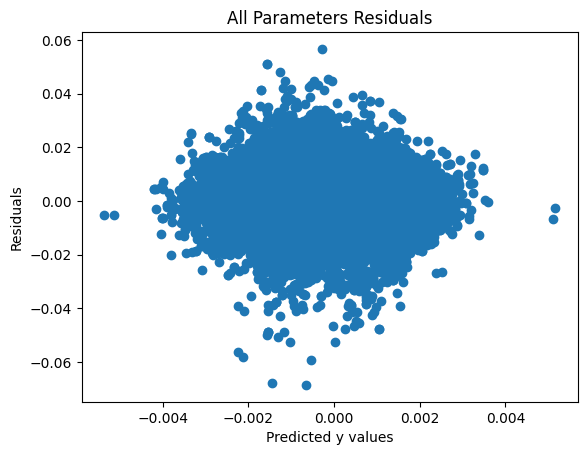

In [393]:
multiple_linreg_eval(X_train, y_train, X_test, y_test, 'All Parameters Residuals')

(np.float64(5.036466912846148e-05),
 array([-1.07102144e-03, -3.57299059e-04, -1.03817387e-04, -4.32627652e-06,
        -3.52729902e-06]),
 np.float64(375.2593903528493),
 np.float64(1.1102230246251565e-16))

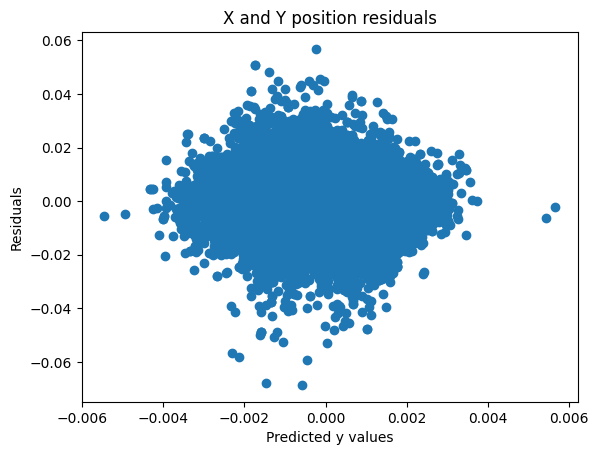

In [394]:
multiple_linreg_eval(X_train[['x_pos_centered', 'y_pos_centered']], y_train, X_test[['x_pos_centered', 'y_pos_centered']], y_test, 'X and Y position residuals')

(np.float64(5.041378049987785e-05),
 array([-1.07102144e-03, -3.57299059e-04, -1.03817387e-04, -4.32627652e-06,
        -3.52729902e-06]),
 np.float64(250.85966011921332),
 np.float64(1.1102230246251565e-16))

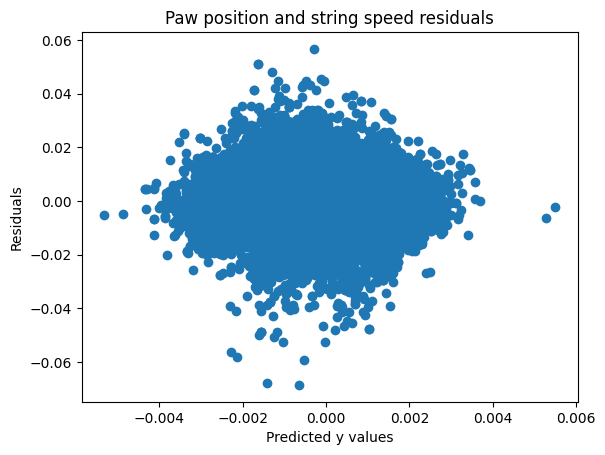

In [395]:
multiple_linreg_eval(X_train[['x_pos_centered', 'y_pos_centered', 'rot_centered']], y_train, 
                     X_test[['x_pos_centered', 'y_pos_centered', 'rot_centered']], y_test, 'Paw position and string speed residuals')

(np.float64(5.036510707585017e-05),
 array([-1.07102144e-03, -3.57299059e-04, -1.03817387e-04, -4.32627652e-06,
        -3.52729902e-06]),
 np.float64(188.16201960339612),
 np.float64(1.1102230246251565e-16))

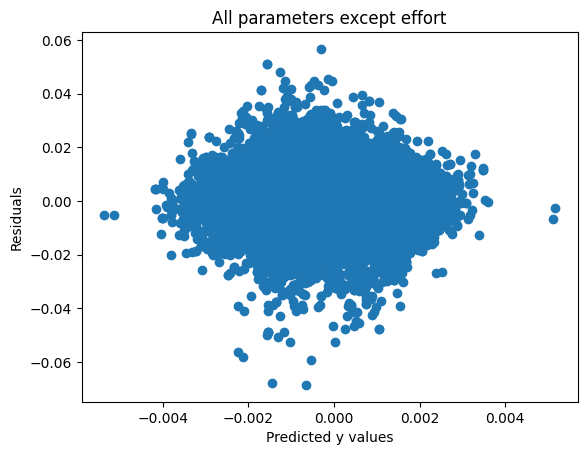

In [396]:
multiple_linreg_eval(X_train[['x_pos_centered', 'y_pos_centered', 'rot_centered', 'paw_vel_centered']],
                      y_train, X_test[['x_pos_centered', 'y_pos_centered', 'rot_centered', 'paw_vel_centered']], y_test, 'All parameters except effort')